In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('logs/forward.csv')
df.head(10)

,elapsed_s,left_rpm,right_rpm,ticks_l,ticks_r,dist_m
0,0.016,0.0,0.0,0,0,0.0000
1,0.081,0.0,0.0,1,1,0.0000
2,0.146,0.6,-0.6,5,4,0.0001
3,0.210,2.3,-2.3,31,31,0.0008
4,0.274,5.0,-5.3,99,105,0.0025
5,0.338,9.1,-8.9,233,239,0.0057
6,0.401,13.3,-13.2,442,441,0.0108
7,0.465,17.6,-18.3,715,733,0.0176
8,0.529,22.5,-22.0,1087,1100,0.0266
9,0.593,25.2,-25.4,1510,1520,0.0369


In [4]:
df.describe()

,elapsed_s,left_rpm,right_rpm,ticks_l,ticks_r,dist_m
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000
mean,2.710718,27.576471,-27.572941,18987.623529,19001.764706,0.462528
std,1.594527,7.328672,7.316703,12833.442818,12834.051180,0.312507
min,0.016000,0.000000,-30.600000,0.000000,0.000000,0.000000
25%,1.351000,29.700000,-30.100000,7688.000000,7702.000000,0.187400
50%,2.697000,30.000000,-29.900000,18725.000000,18733.000000,0.456100
75%,4.071000,30.100000,-29.700000,29984.000000,29997.000000,0.730300
max,5.437000,30.700000,0.000000,41188.000000,41196.000000,1.003000


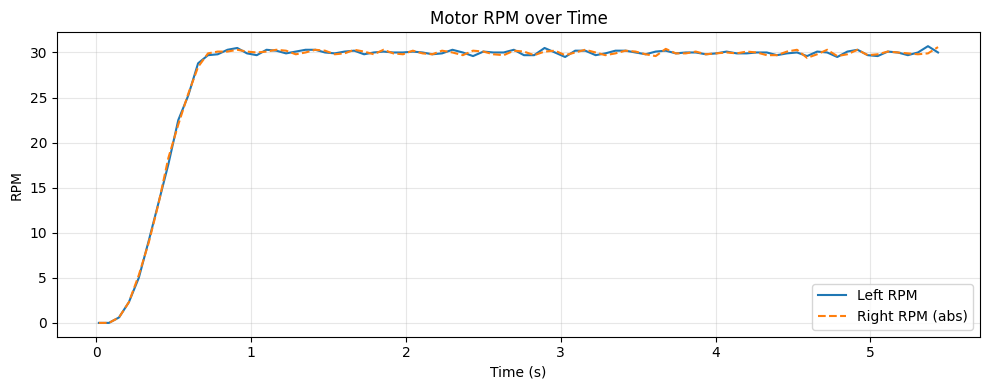

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['elapsed_s'], df['left_rpm'], label='Left RPM')
ax.plot(df['elapsed_s'], df['right_rpm'].abs(), label='Right RPM (abs)', linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('RPM')
ax.set_title('Motor RPM over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

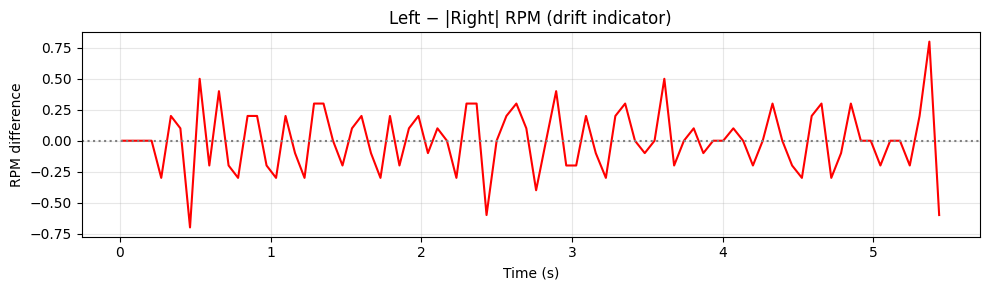

Mean RPM diff: 0.00
Std  RPM diff: 0.26


In [6]:
df['rpm_diff'] = df['left_rpm'] - df['right_rpm'].abs()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df['elapsed_s'], df['rpm_diff'], color='red')
ax.axhline(0, color='gray', linestyle=':')
ax.set_xlabel('Time (s)')
ax.set_ylabel('RPM difference')
ax.set_title('Left − |Right| RPM (drift indicator)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mean RPM diff: {df["rpm_diff"].mean():.2f}')
print(f'Std  RPM diff: {df["rpm_diff"].std():.2f}')

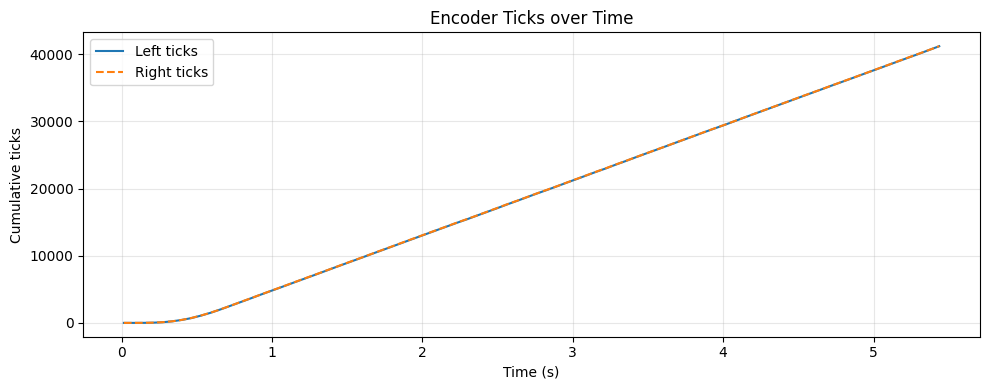

Final ticks — L: 41188  R: 41196
Tick difference (L-R): -8


In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['elapsed_s'], df['ticks_l'], label='Left ticks')
ax.plot(df['elapsed_s'], df['ticks_r'], label='Right ticks', linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cumulative ticks')
ax.set_title('Encoder Ticks over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final ticks — L: {df["ticks_l"].iloc[-1]}  R: {df["ticks_r"].iloc[-1]}')
print(f'Tick difference (L-R): {df["ticks_l"].iloc[-1] - df["ticks_r"].iloc[-1]}')

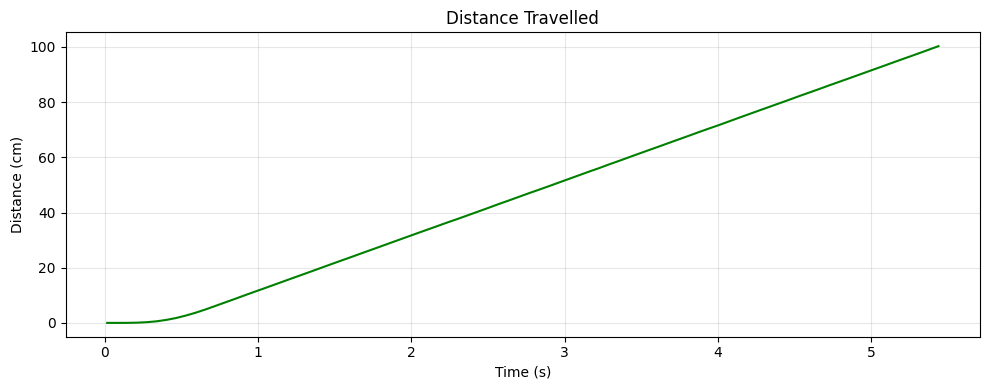

Total distance: 100.3 cm
Total time: 5.44 s


In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['elapsed_s'], df['dist_m'] * 100, color='green')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Distance (cm)')
ax.set_title('Distance Travelled')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total distance: {df["dist_m"].iloc[-1]*100:.1f} cm')
print(f'Total time: {df["elapsed_s"].iloc[-1]:.2f} s')

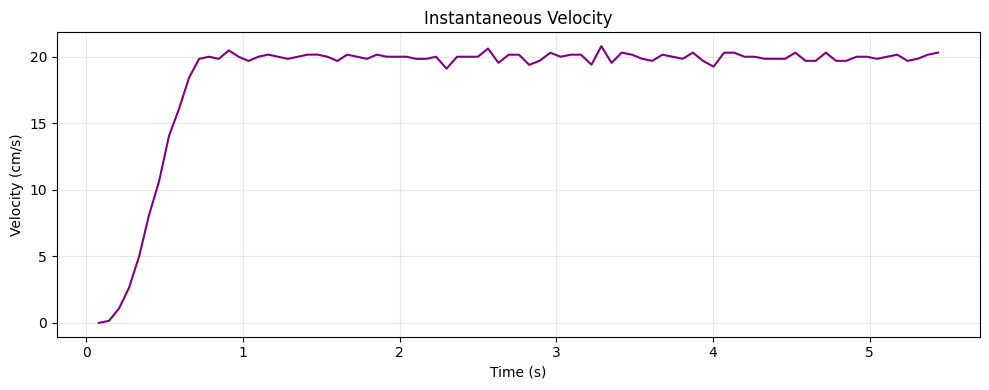

In [9]:
dt = df['elapsed_s'].diff()
dd = df['dist_m'].diff()
df['velocity_ms'] = dd / dt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['elapsed_s'], df['velocity_ms'] * 100, color='purple')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Velocity (cm/s)')
ax.set_title('Instantaneous Velocity')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

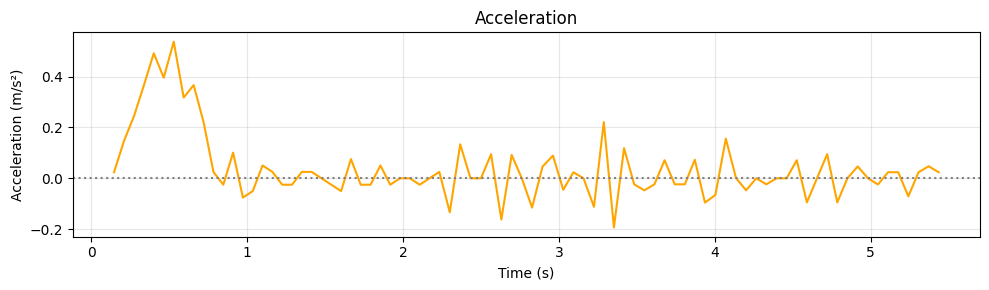

In [10]:
df['accel'] = df['velocity_ms'].diff() / dt

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df['elapsed_s'], df['accel'], color='orange')
ax.axhline(0, color='gray', linestyle=':')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Acceleration (m/s²)')
ax.set_title('Acceleration')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
peak_rpm = df['left_rpm'].max()
peak_vel = df['velocity_ms'].max() * 100
total_dist = df['dist_m'].iloc[-1] * 100
total_time = df['elapsed_s'].iloc[-1]
tick_diff = df['ticks_l'].iloc[-1] - df['ticks_r'].iloc[-1]

print('=== Forward Run Summary ===')
print(f'Duration:       {total_time:.2f} s')
print(f'Distance:       {total_dist:.1f} cm')
print(f'Peak RPM:       {peak_rpm:.1f}')
print(f'Peak velocity:  {peak_vel:.1f} cm/s')
print(f'Avg velocity:   {total_dist/total_time:.1f} cm/s')
print(f'Tick imbalance: {tick_diff} (L-R)')

=== Forward Run Summary ===
Duration:       5.44 s
Distance:       100.3 cm
Peak RPM:       30.7
Peak velocity:  20.8 cm/s
Avg velocity:   18.4 cm/s
Tick imbalance: -8 (L-R)
